# Phytoplankton Phenology Study in the Northwest Atlantic Ocean

#### Import Python Libraries

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import pandas as pd
from shapely.ops import unary_union
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import mapping
import rioxarray
import sys
sys.path.append(r'C:\Users\grace.davis\Documents\GitHub\RESOURCES\python')
import utilities
from utilities import get_prod_files
import cmocean

## Part 1: Bloom Detection Method Testing

### Threshold Method

#### Step 1: Set the threshold percentage variable

In [ ]:
#Enter a threshold percentage as a decimal, the default is 0.05
thld = 0.05

#### Step 2: Determine the threshold value
1. Use the annual climatology for the time series (1997-2020)
1. Find the median value of chlorophyll a
1. Add median + threshold percentage to get the threshold value for the dataset (median*(1+threshold percentage))
1. Create a variable for the threshold value

In [ ]:
#Define a function to return the threshold value based on the regional climatology.
def threshold_value(thld = 0.05, path = None):
    if path == None:
        file = get_prod_files('CHL',mapping='NES',period='ANNUAL',verbose=True) #finds path for the annual climatology file
        base_ds = xr.open_dataset(file[0]) #opens netCDF file
    else:
        base_ds = xr.open_dataset(path)
    median_CHL = base_ds.CHL_median #grabs CHL_median variable
    thld_value = median_CHL*(1+thld) #Sets threshold value per latitude and longitude point
    return(thld_value)

clim_med = threshold_value()
#print(clim_med)

#### Plotting the Climatological Threshold

Text(0.5, 1.0, 'Chlorophyll a Climatological Median Threshold')

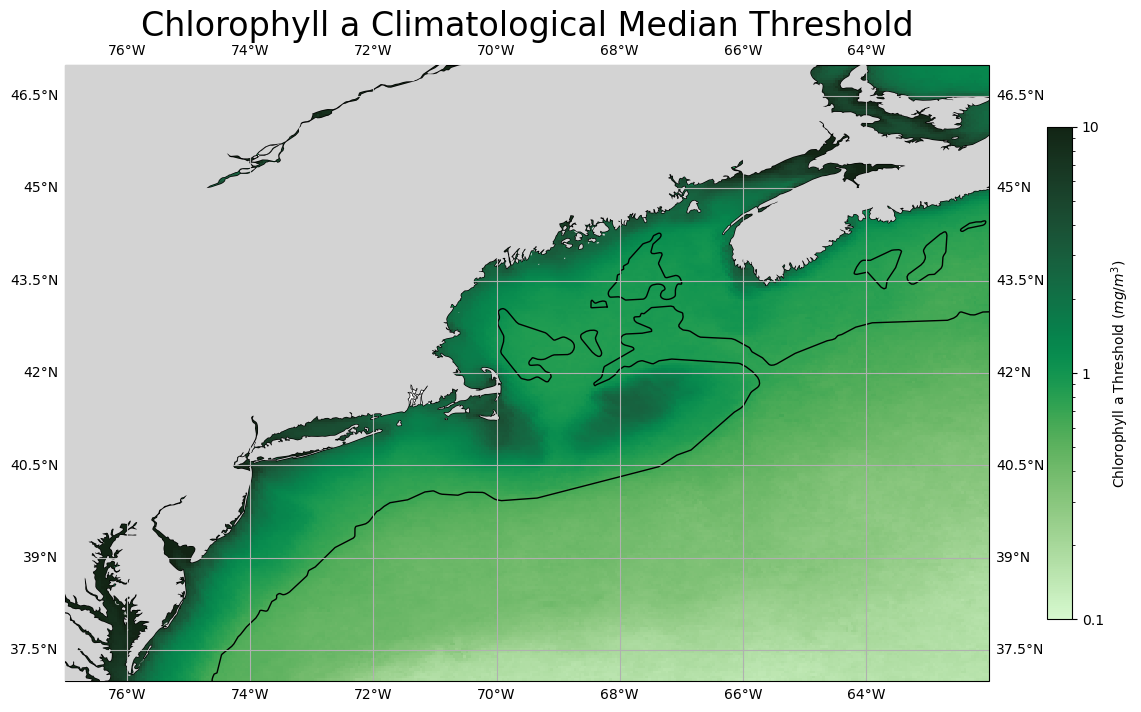

In [89]:
clim_med = clim_med.squeeze()
from matplotlib.colors import LogNorm
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
fig = plt.figure(figsize=(15,8))
map_projection = cartopy.crs.PlateCarree()
ax = plt.axes(projection=map_projection)
im = plt.pcolormesh(clim_med.lon,
                    clim_med.lat,
                    clim_med,
                    cmap=cmocean.cm.algae,
                    norm=LogNorm(vmin=0.1, vmax=10.0)
)
custom_ticks = [0.1,1,10]
cb = plt.colorbar(im,shrink=0.8,label='Chlorophyll a Threshold ($mg/m^3$)',ticks=custom_ticks,format='%g') #$ $ makes it a LaTEX function so it actually formats as an equation

ax.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree()) #Adding the shelf break line
ax.set_extent([-77,-62,37,47])
ax.set_xlabel('Longitude ($^o$)', fontsize=12)
ax.set_ylabel('Latitude ($^o$)', fontsize=12)
ax.gridlines(draw_labels=True)
ax.set_title('Chlorophyll a Climatological Median Threshold', fontsize=24)

#### Step 3: Create a mask to filter data for bloom conditions
1. Mask out clouds and other missing data as necessary
1. Create a mask to filter between data that exceeds the threshold and data that does not meet it.
1. If the value is less than the threshold value, make it equal to 0 (or NaN, whatever we choose)
1. If it is greater than or equal to the threshold value, make sure it retains its true value
1. Save the retained files in a single variable for plotting

In [ ]:
clim_med = threshold_value()
def bloom_mask_Boolean(path=None): #Produces True and False values
    if path == None:
        files = get_prod_files('CHL',mapping='NES',period='D8') #Finds all 8 day rolling mean files for NWA
        ds = xr.open_mfdataset(files)
    else:
        ds = xr.open_mfdataset(path)
    med_CHL = ds.CHL_median #Extracts CHL_mean variable for the files
    clim_med_new = clim_med.squeeze('time', drop=True) #Removes time dimension from climatological mean
    is_bloom_CHL = med_CHL > clim_med #Is the median chl-a in each files greater than the climatological mean? Creates a Boolean array of trues and falses.
    return is_bloom_CHL

In [ ]:
def bloom_mask_numeric(path=None): #Produces 0 and actual values
    if path == None:
        files = get_prod_files('CHL',mapping='NES',period='D8') #Finds all 8 day rolling mean files for NWA
        ds = xr.open_mfdataset(files)
    else:
        ds = xr.open_mfdataset(path)
    med_CHL = ds.CHL_median #Extracts CHL_mean variable for the files
    clim_med_new = clim_med.squeeze('time', drop=True) #Removes time dimension from climatological mean, FIX THIS LINE
    is_bloom_CHL = med_CHL.where(med_CHL > clim_med_new, 0) #Turns false into 0 and trues retain their value
    return is_bloom_CHL

bloom = bloom_mask_numeric()

#### Plotting the Mask

In [ ]:
from matplotlib.colors import LogNorm
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
fig = plt.figure(figsize=(15,8))
map_projection = cartopy.crs.PlateCarree()
ax = plt.axes(projection=map_projection)
im = plt.pcolormesh(bloom[0].lon,
                    bloom[0].lat,
                    bloom[0],
                    cmap=cmocean.cm.algae,
                    norm=LogNorm(vmin=0.1, vmax=10.0)
)
custom_ticks = [0.1,1,10]
cb = plt.colorbar(im,shrink=0.8,label='Chlorophyll a Threshold ($mg/m^3$)',ticks=custom_ticks,format='%g') #$ $ makes it a LaTEX function so it actually formats as an equation

ax.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree()) #Adding the shelf break line
ax.set_extent([-77,-63,34.5,46])
ax.set_xlabel('Longitude ($^o$)', fontsize=12)
ax.set_ylabel('Latitude ($^o$)', fontsize=12)
gl=ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
ax.set_title('Chlorophyll a Mask', fontsize=24)

#### Mask Intervals

In [ ]:
thld_value = [0.05,0.1,0.15,0.2,0.25,0.3]
clim_med = threshold_value()
bloom_5 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[1])
bloom_10 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[2])
bloom_15 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[3])
bloom_20 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[4])
bloom_25 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[5])
bloom_30 = bloom_mask_numeric()

Text(0.5, 0.98, 'Chlorophyll a Masks Based on NES Annual Climatology')

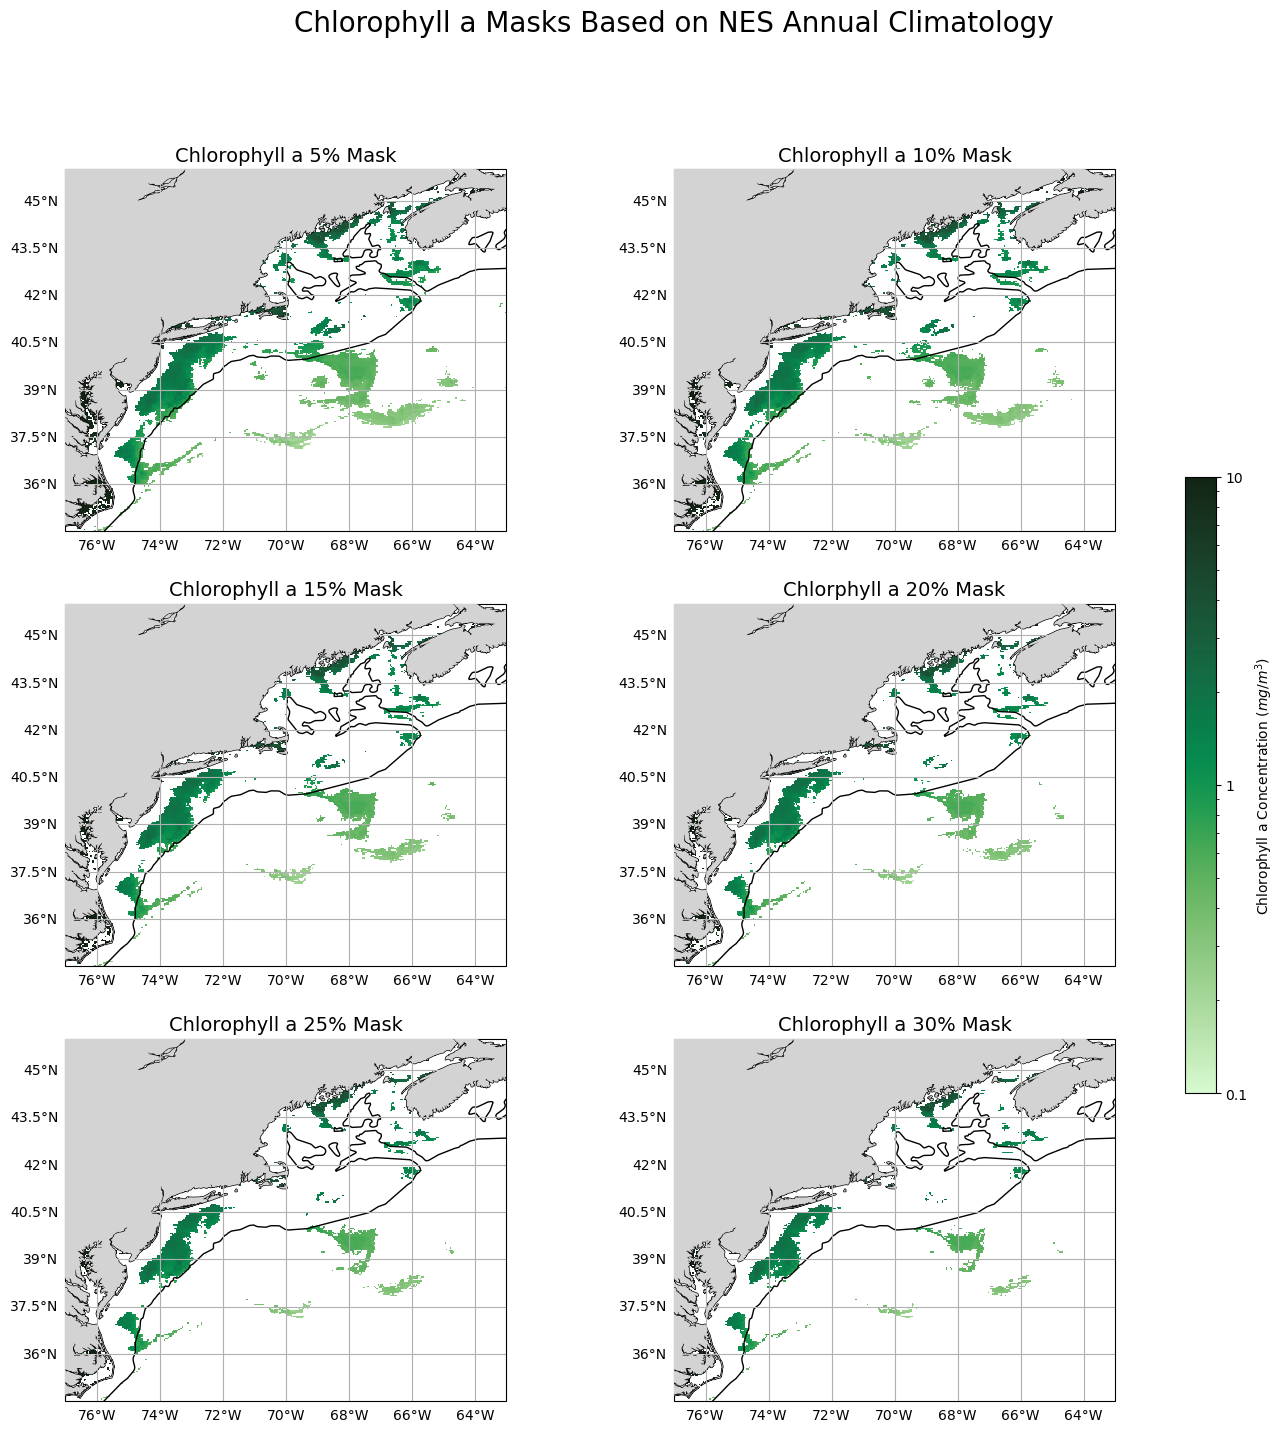

In [90]:
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
map_projection = cartopy.crs.PlateCarree()

DOY = 7181
datasets = [
    (bloom_5[DOY],"Chlorophyll a 5% Mask"),
    (bloom_10[DOY], "Chlorophyll a 10% Mask"),
    (bloom_15[DOY], "Chlorophyll a 15% Mask"),
    (bloom_20[DOY], "Chlorphyll a 20% Mask"),
    (bloom_25[DOY], "Chlorophyll a 25% Mask"),
    (bloom_30[DOY], "Chlorophyll a 30% Mask"),
    ]

fig, axes = plt.subplots(3,2,figsize=(18,16),subplot_kw={"projection":map_projection})
axes_flat = axes.flatten()

im= None

for i, (data,title) in enumerate(datasets):
    ax = axes_flat[i]
    im = ax.pcolormesh(data.lon,
                data.lat,
                data,
                cmap=cmocean.cm.algae,
                norm=LogNorm(vmin=0.1, vmax=10.0)
    )
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1)
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
    ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree()) #Adding the shelf break line
    ax.set_xlabel('Longitude ($^o$)', fontsize=12)
    ax.set_ylabel('Latitude ($^o$)', fontsize=12)
    ax.set_extent([-77,-63,34.5,46])
    ax.set_title(title, fontsize=14) #Plot headings
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

custom_ticks = [0.1,1,10]
cb = fig.colorbar(im,ax=axes,shrink=0.5,label='Chlorophyll a Concentration ($mg/m^3$)',ticks=custom_ticks,format='%g')
fig.suptitle("Chlorophyll a Masks Based on NES Annual Climatology",fontsize=20) #Overall figure heading

#### Histograms of Data

In [ ]:
clim = xr.open_dataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL\ANNUAL_1998_2020-OCCCI-CHL-NES-STATS.nc')
clim_med = clim.CHL_median
lat_min, lat_max = 43.5, 41.5
lon_min, lon_max = -70, -68
clim_med = clim_med.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
)
clim_med_bounded = clim_med.mean(dim=['lat','lon'])
print(clim_med_bounded)
clim_5 = clim_med_bounded*1.05
clim_10 = clim_med_bounded*1.1
clim_15 = clim_med_bounded*1.15
clim_20 = clim_med_bounded*1.2
clim_25 = clim_med_bounded*1.25
clim_30 = clim_med_bounded*1.3

In [ ]:
ds = xr.open_mfdataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8*.nc')

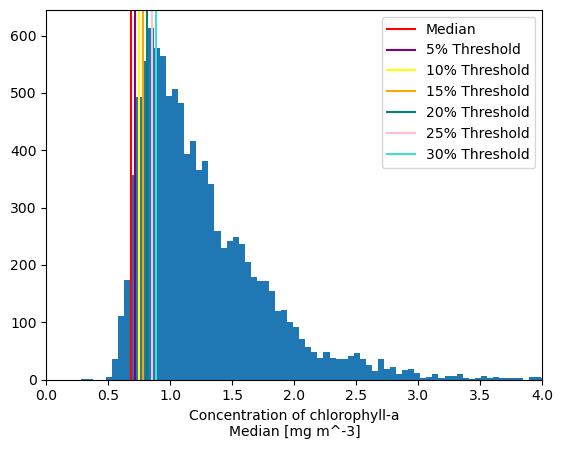

In [91]:
#Gulf of Maine
lat_min, lat_max = 44, 43
lon_min, lon_max = -69, -68
ds_GOM = ds.CHL_median.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
)
ds_GOM = ds_GOM.mean(dim=['lat','lon'])
fig
ds_GOM.plot.hist(bins=100)
plt.xlim(0,4)
plt.axvline(clim_med_bounded, color='red',label='Median')
plt.axvline(clim_5, color='purple', label='5% Threshold')
plt.axvline(clim_10, color='yellow',label='10% Threshold')
plt.axvline(clim_15, color='orange',label='15% Threshold')
plt.axvline(clim_20, color='teal',label='20% Threshold')
plt.axvline(clim_25, color='pink',label='25% Threshold')
plt.axvline(clim_30, color='turquoise',label='30% Threshold')
plt.legend()

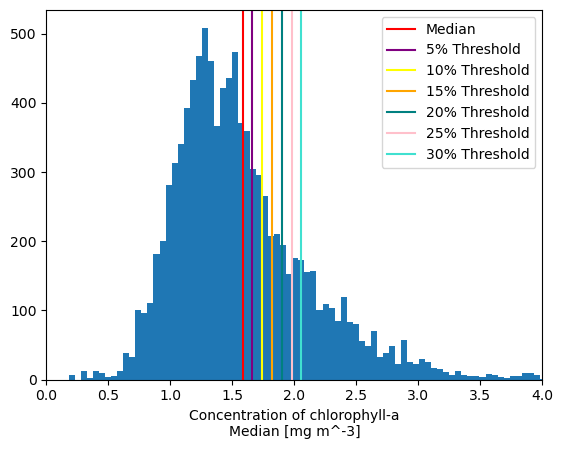

In [92]:
#Georges Bank
lat_min, lat_max = 41.7, 40.7
lon_min, lon_max = -68, -67
ds_GB = ds.CHL_median.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
)
ds_GB = ds_GB.mean(dim=['lat','lon'])
fig
ds_GB.plot.hist(bins=100)
plt.xlim(0,4)
clim_med = clim.CHL_median
lat_min, lat_max = 41.7, 40.7
lon_min, lon_max = -68, -67
clim_med = clim_med.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
)
clim_med_bounded = clim_med.mean(dim=['lat','lon'])
clim_5 = clim_med_bounded*1.05
clim_10 = clim_med_bounded*1.1
clim_15 = clim_med_bounded*1.15
clim_20 = clim_med_bounded*1.2
clim_25 = clim_med_bounded*1.25
clim_30 = clim_med_bounded*1.3

plt.axvline(clim_med_bounded, color='red',label='Median')
plt.axvline(clim_5, color='purple', label='5% Threshold')
plt.axvline(clim_10, color='yellow',label='10% Threshold')
plt.axvline(clim_15, color='orange',label='15% Threshold')
plt.axvline(clim_20, color='teal',label='20% Threshold')
plt.axvline(clim_25, color='pink',label='25% Threshold')
plt.axvline(clim_30, color='turquoise',label='30% Threshold')
plt.legend()

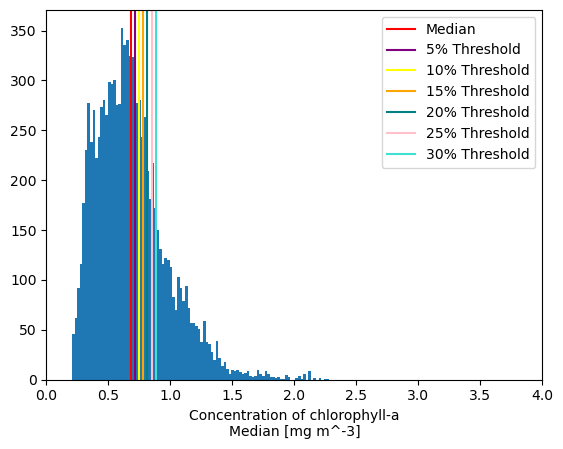

In [93]:
#Middle Atlantic Bight
lat_min, lat_max = 40, 39
lon_min, lon_max = -73, -72
ds_MAB = ds.CHL_median.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
)
ds_MAB = ds_MAB.mean(dim=['lat','lon'])
fig
ds_MAB.plot.hist(bins=100)
plt.xlim(0,4)

clim_med = clim.CHL_median
lat_min, lat_max = 40, 39
lon_min, lon_max = -73, -72
clim_med = clim_med.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
)
clim_med_bounded = clim_med.mean(dim=['lat','lon'])
clim_5 = clim_med_bounded*1.05
clim_10 = clim_med_bounded*1.1
clim_15 = clim_med_bounded*1.15
clim_20 = clim_med_bounded*1.2
clim_25 = clim_med_bounded*1.25
clim_30 = clim_med_bounded*1.3

plt.axvline(clim_med_bounded, color='red',label='Median')
plt.axvline(clim_5, color='purple', label='5% Threshold')
plt.axvline(clim_10, color='yellow',label='10% Threshold')
plt.axvline(clim_15, color='orange',label='15% Threshold')
plt.axvline(clim_20, color='teal',label='20% Threshold')
plt.axvline(clim_25, color='pink',label='25% Threshold')
plt.axvline(clim_30, color='turquoise',label='30% Threshold')
plt.legend()

In [ ]:
#Adding variable to netCDF file
from netCDF4 import Dataset
path = r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NWA_4KM_DAY8\CHL\D8_19980102_19980109-OCCCI-CHL-NWA-STATS.nc'
ds = xr.open_dataset(path)
cdf = bloom_mask_numeric(path=path) #Creates masked variable
ds['five_percent_thld'] = cdf #Adds variable to ds
ds.to_netcdf(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NWA_4KM_DAY8\CHL\D8_19980102_19980109-OCCCI-CHL-NWA-STATS_with_threshold.nc') #Renames the file and saves it with the new variable

### Rate of Change

#### Step 0: Test with climatology data

In [ ]:
def rate_of_change(path=None, lat = 41, lon=-71):
    if path == None:
        files = get_prod_files('CHL',map_region='NES',period='WEEK')
        clim_med = xr.open_mfdataset(files)
    else:
        clim_med = xr.open_dataset(path)
    clim_med = clim_med.CHL_median
    clim_median=clim_med.to_dataframe(name='Chl-a') #Converts it into a pandas dataframe
    clim_roc = clim_median.diff() #Calculate rate of change between each data point
    return clim_roc

roc = rate_of_change()
print(roc)

#def max_roc(days=15,prm=0.2): #Days between peaks and the relative height of each peak value
    #roc = rate_of_change()
    #roc_max = roc.Chl_a.find_peaks(days=days,prominence=prm)
    #return roc_max

#roc_max_values = max_roc
#print(roc_max_values)

#### Step 1: Calculate instantaneous rate of change for each day
1. Make pandas dataframe of chlorophyl data
1. .diff() function
1. Store that in another array

#### Step 2: Set parameters for bloom intiation dates
1. Number of days between start dates
1. Prominence: height of slope peak compared to relative surrounding data
1. Height: Height required (min and/or max) for a peak

#### Step 3: Identify maximum rates of change
Use .find_peaks() function or .find_peaks_cwt() if the data is too noisy

#### Step 4: Extract dates of maximum rates of change

## Part 2: Quantify the Number of Phytoplankton Bloom Days Per Year

#### Actual number of bloom days per year over the time series

Based on the method(s) chosen in Part 1:
1. For each year: 365 - bloom
1. Plot the time series of the data to verify qualitatively

Quantifying bloom days
1. Separate the data out by year
    1. Run the mask for just yearly data?
1. How many daily files meet the bloom criteria?
1. Subtract the bloom daily files from the number of days that year.

Plotting the time series

In [ ]:
path = r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_1998*.nc'
files = xr.open_mfdataset(path)
#clim_files = xr.open_dataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL\ANNUAL_1998_2020-OCCCI-CHL-NES-STATS.nc')
#print(clim_files)

In [ ]:
med_CHL = files.CHL_median
med_CHL = med_CHL.median(dim=['lat','lon'])
clim_med = clim_files.CHL_median.sel(lat=slice())

In [ ]:
med_CHL = files.CHL_median
med_CHL = med_CHL.median(dim=['lat','lon'])
#clim_med_CHL = clim_files.CHL_median
#clim_med_CHL = clim_med_CHL.groupby('time.dayofyear').first() #Makes days numbered 1-365
#clim_med_CHL = clim_med_CHL.sel(dayofyear=med_CHL.time.dt.dayofyear) #Matches climatology dates (1-365) with the same day of year in the 1998 file
#clim_med_CHL = clim_med_CHL.median(dim=['lat','lon'])
#clim_thld = clim_med_CHL*(1.05)
fig = plt.figure(figsize=(15,8))
plt.plot(med_CHL.time.values,med_CHL,c='purple',label='Median CHL')
#plt.plot(clim_med_CHL.time.values,clim_med_CHL,c='orange',label='Climatological Median')
#plt.plot(clim_thld.time.values,clim_thld,c='teal',label='5% Threshold')
plt.legend()
plt.xticks(rotation=45)
plt.ylabel('Chlorophyll a ($mg/m^3$)')
plt.xlabel('Date')
#upper_error = clim_med_CHL*0.05
#lower_error = np.zeros_like(upper_error) #creates an array of zeroes
#error = [lower_error,upper_error]
#plt.errorbar(clim_med_CHL.time.values,clim_med_CHL,yerr=error,c='orange')
plt.title('1998 Chlorophyll a for NES')

#### Average number of bloom days over the time series

Using the data from above:
1. Calculate the mean (median) number of bloom days for the time series
1. Create an array of the actual days of year
1. Run median (and mean) statistics on the array

## Part 3: Quantify the Number of Phytoplankton Blooms Per Year

#### Actual number of phytoplankton blooms per year over the time series

1. Find the number of peaks (where derivative is 0) above the threshold/place where bloom conditions begin
2. Verify qualitatively with time series

#### Average number of phytoplankton blooms per year over the time series

## Part 4: Bloom Characteristics Analysis

#### Bloom start day

#### Duration of blooms

#### Maximum chlorophyll a

#### Minimum chlorophyll a

#### Mean chlorophyll a

#### Integrated chlorophyll a

#### Location of blooms
1. Find the center of gravity of major blooms

#### Periodicity of Blooms